# 03. Master Dataset EDA (Εξερευνητική Ανάλυση Δεδομένων)

Σε αυτό το Notebook θα πραγματοποιήσουμε τη **συνολική ανάλυση** του DaKS Dataset, φορτώνοντας και τα **271 αιολικά πάρκα** που περάσανε επιτυχώς τον έλεγχο ποιότητας.

### Στόχοι:
1.  **Μαζική Φόρτωση:** Χρήση του `KasselLoader` για τη δημιουργία ενός ενιαίου Master DataFrame.
2.  **Έλεγχος Ποιότητας:** Εντοπισμός κενών τιμών (missing values) και ανωμαλιών σε όλο το φάσμα των δεδομένων.
3.  **Στατιστική Ανάλυση:** Υπολογισμός μέσων τιμών, τυπικών αποκλίσεων και κατανομών για την Ταχύτητα Ανέμου και την Ισχύ.
4.  **Οπτικοποίηση:** Δημιουργία γραφημάτων για την κατανόηση της συμπεριφοράς του στόλου των ανεμογεννητριών.

---

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. Ρύθμιση για να βλέπει το Notebook τον φάκελο src
# (Απαραίτητο για να βρούμε τον Loader)
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from src.data.kassel_loader import KasselLoader

# Ρύθμιση εμφάνισης γραφημάτων
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Εκκίνηση δημιουργίας Master Dataset...")

# 2. Αρχικοποίηση του Loader
loader = KasselLoader("../data/raw/kassel_dataset")
park_ids = loader.get_available_parks()

print(f" Βρέθηκαν {len(park_ids)} διαθέσιμα πάρκα.")

# 3. Φόρτωση Δεδομένων
# Θα φορτώσουμε όλα τα πάρκα σε μία λίστα
all_dfs = []

# Προσοχή: Αν ο υπολογιστής κολλάει, άλλαξε το park_ids σε park_ids[:50] για δοκιμή
for pid in tqdm(park_ids, desc="Loading Parks"):
    try:
        df = loader.load_park_data(pid)
        if df is not None:
            # Προσθέτουμε μια στήλη 'park_id' για να ξέρουμε από ποιο πάρκο είναι η κάθε γραμμή
            df['park_id'] = pid
            all_dfs.append(df)
    except Exception as e:
        print(f"Σφάλμα στο πάρκο {pid}: {e}")

# 4. Ένωση (Concatenation)
if all_dfs:
    master_df = pd.concat(all_dfs)
    print("\n ΕΠΙΤΥΧΙΑ! Το Master Dataset δημιουργήθηκε.")
    print(f"Συνολικές Γραμμές: {len(master_df):,}")
    print(f"Στήλες: {master_df.columns.tolist()}")
    
    # Εμφάνιση των πρώτων γραμμών
    display(master_df.head())
else:
    print("Κάτι πήγε στραβά, δεν φορτώθηκαν δεδομένα.")

Εκκίνηση δημιουργίας Master Dataset...
KasselLoader Initialized: Καταλογογραφήθηκαν 273 πάρκα.
 Βρέθηκαν 272 διαθέσιμα πάρκα.


Loading Parks:   0%|          | 0/272 [00:00<?, ?it/s]


 ΕΠΙΤΥΧΙΑ! Το Master Dataset δημιουργήθηκε.
Συνολικές Γραμμές: 3,355,233
Στήλες: ['fcst_time', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Power_Output_Normalized', 'Baseline_Prediction', 'park_id']


,fcst_time,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,ASWDIFDS_SFC_0_M,...,U_GVL_58_HL_p1,V_GVL_58_HL_p1,U_GVL_60_HL_p1,V_GVL_60_HL_p1,ws_ref,Wind_Speed_100m_ms,test_flag,Power_Output_Normalized,Baseline_Prediction,park_id
time,,,,,,,,,,,,,,,,,,,,,
2018-12-12 00:00:00,12/12/2018 0:00,24,269725,92373,93686352,127,-354,422,-120,18578,...,402,121,577,170,0.376092,0.406559,0,0.001,0.0,00011
2018-12-12 01:00:00,12/12/2018 1:00,25,269547,91783,93673273,193,-641,538,-99,17836,...,127,-354,422,-120,0.669425,0.723655,0,0.0,0.0,00011
2018-12-12 02:00:00,12/12/2018 2:00,26,269285,91758,93675902,152,-380,487,58,17148,...,193,-641,538,-99,0.409273,0.442428,0,0.0,0.0,00011
2018-12-12 03:00:00,12/12/2018 3:00,27,269198,91159,93641559,-90,-378,420,-4,16514,...,152,-380,487,58,0.388567,0.420044,0,0.0,0.0,00011
2018-12-12 04:00:00,12/12/2018 4:00,28,269304,90048,93654922,-20,-465,452,-80,15924,...,-90,-378,420,-4,0.46543,0.503134,0,0.0,0.0,00011


In [2]:
print("Έλεγχος Περιεχομένου Master Dataset:")

# 1. Δες τις τελευταίες γραμμές (Λογικά θα δεις το πάρκο 062something)
print("\n--- Τελευταίες 5 Γραμμές ---")
display(master_df.tail())

# 2. Μέτρησε πόσα διαφορετικά πάρκα υπάρχουν στη στήλη 'park_id'
unique_parks = master_df['park_id'].nunique()
print(f"\n Βρέθηκαν {unique_parks} μοναδικά πάρκα μέσα στο Master Dataset!")

# 3. Δείξε μου μια λίστα με 10 τυχαία πάρκα που υπάρχουν μέσα
print("\n--- Δείγμα 10 Πάρκων ---")
print(master_df['park_id'].unique()[:10]) # Δείχνει τα 10 πρώτα ID
print("...")
print(master_df['park_id'].unique()[-10:]) # Δείχνει τα 10 τελευταία ID

Έλεγχος Περιεχομένου Master Dataset:

--- Τελευταίες 5 Γραμμές ---


,fcst_time,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,ASWDIFDS_SFC_0_M,...,U_GVL_58_HL_p1,V_GVL_58_HL_p1,U_GVL_60_HL_p1,V_GVL_60_HL_p1,ws_ref,Wind_Speed_100m_ms,test_flag,Power_Output_Normalized,Baseline_Prediction,park_id
time,,,,,,,,,,,,,,,,,,,,,
2020-01-06 19:00:00,2020-06-01 19:00:00,43,292.886,40.095,98388.578,-5.611,-2.196,-1.946,-0.902,105.512,...,-6.158,-1.794,-3.011,-0.968,0.006025,0.006514,1,0.026,0.101,15978
2020-01-06 20:00:00,2020-06-01 20:00:00,44,290.136,42.078,98423.855,-5.316,-2.357,-1.536,-0.876,103.172,...,-5.611,-2.196,-1.946,-0.902,0.005815,0.006286,1,0.026,0.091,15978
2020-01-06 21:00:00,2020-06-01 21:00:00,45,287.304,52.158,98451.723,-4.772,-2.445,-1.214,-0.792,100.878,...,-5.316,-2.357,-1.536,-0.876,0.005362,0.005796,1,0.0,0.07,15978
2020-01-06 22:00:00,2020-06-01 22:00:00,46,285.591,59.665,98461.121,-4.485,-2.799,-1.101,-1.001,98.686,...,-4.772,-2.445,-1.214,-0.792,0.005287,0.005715,1,0.0,0.066,15978
2020-01-06 23:00:00,2020-06-01 23:00:00,47,284.863,64.481,98468.363,-5.094,-2.524,-1.275,-0.903,96.585,...,-4.485,-2.799,-1.101,-1.001,0.005685,0.006146,1,0.0,0.085,15978



 Βρέθηκαν 271 μοναδικά πάρκα μέσα στο Master Dataset!

--- Δείγμα 10 Πάρκων ---
<StringArray>
['00011', '00090', '00096', '00161', '00164', '00183', '00197', '00198',
 '00232', '00282']
Length: 10, dtype: str
...
<StringArray>
['15189', '15190', '15200', '15207', '15214', '15444', '15520', '15547',
 '15976', '15978']
Length: 10, dtype: str


In [3]:
# --- 1. Έλεγχος Ποιότητας ---
print("Έλεγχος Κενών Τιμών (Missing Values) στο Master Dataset:")
nulls = master_df.isnull().sum()
# Εμφανίζουμε μόνο τις στήλες που έχουν πρόβλημα (αν υπάρχουν)
print(nulls[nulls > 0])

print("\n Στατιστική Περιγραφή:")
# Κοιτάμε τα στατιστικά για τον Άνεμο και την Ισχύ
display(master_df[['Wind_Speed_100m_ms', 'Power_Output_Normalized']].describe())

Έλεγχος Κενών Τιμών (Missing Values) στο Master Dataset:
Series([], dtype: int64)

 Στατιστική Περιγραφή:


,Wind_Speed_100m_ms,Power_Output_Normalized
count,3.355233e+06,3355233.0
unique,2.983929e+06,809.0
top,1.268081e-03,0.0
freq,1.100000e+01,425025.0


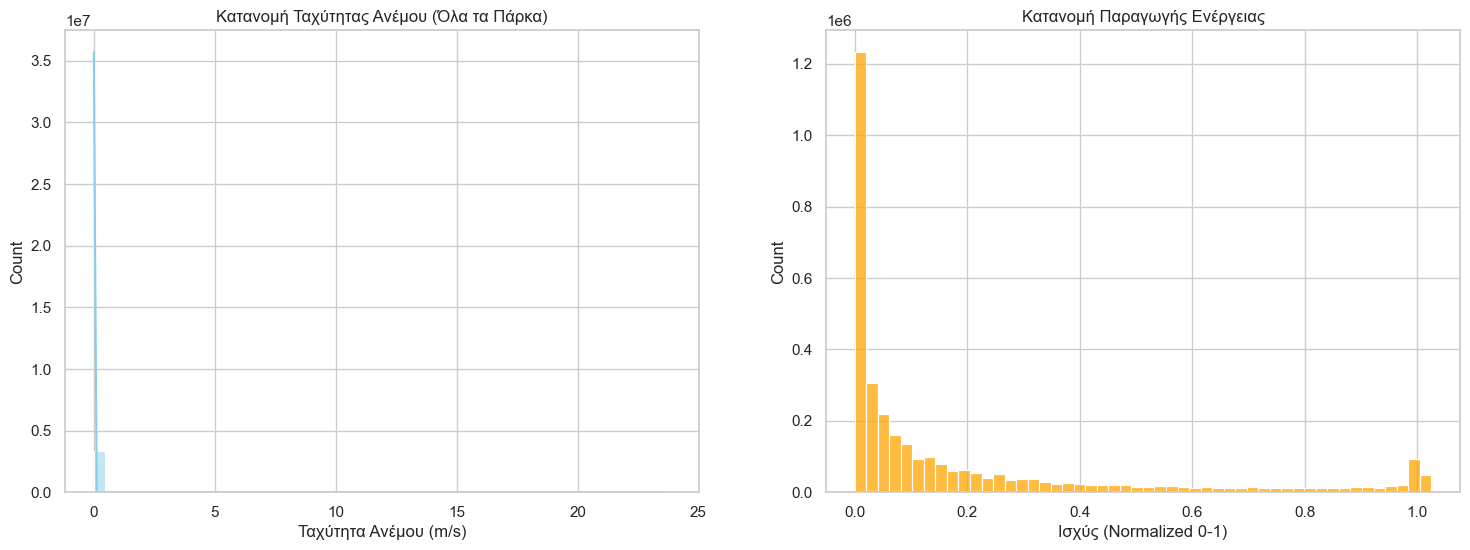

In [4]:
# --- 2. Οπτικοποίηση Κατανομών ---
import matplotlib.pyplot as plt
import seaborn as sns

# Ρύθμιση μεγέθους
plt.figure(figsize=(18, 6))

# Γράφημα 1: Άνεμος
plt.subplot(1, 2, 1)
sns.histplot(master_df['Wind_Speed_100m_ms'], bins=50, kde=True, color='skyblue')
plt.title('Κατανομή Ταχύτητας Ανέμου (Όλα τα Πάρκα)')
plt.xlabel('Ταχύτητα Ανέμου (m/s)')

# Γράφημα 2: Ισχύς
plt.subplot(1, 2, 2)
sns.histplot(master_df['Power_Output_Normalized'], bins=50, kde=False, color='orange')
plt.title('Κατανομή Παραγωγής Ενέργειας')
plt.xlabel('Ισχύς (Normalized 0-1)')

plt.show()

Δημιουργία Καμπύλης Ισχύος (με δείγμα 50.000 σημείων)...


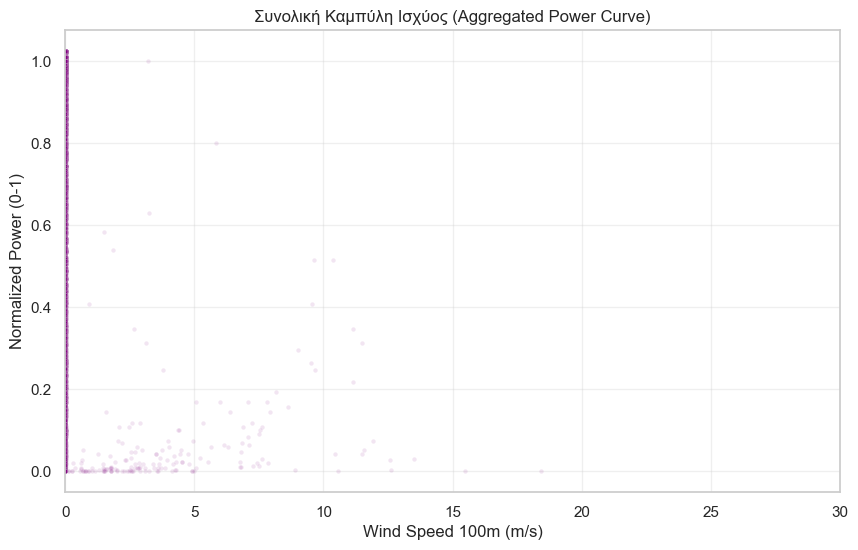

In [5]:
# --- 3. Καμπύλη Ισχύος (Power Curve) ---
print("Δημιουργία Καμπύλης Ισχύος (με δείγμα 50.000 σημείων)...")

# Παίρνουμε τυχαίο δείγμα
sample_df = master_df.sample(n=50000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df, 
    x='Wind_Speed_100m_ms', 
    y='Power_Output_Normalized', 
    alpha=0.1,       # Διαφάνεια για να βλέπουμε την πυκνότητα
    s=10,            # Μέγεθος κουκκίδας
    color='purple'
)

plt.title('Συνολική Καμπύλη Ισχύος (Aggregated Power Curve)')
plt.xlabel('Wind Speed 100m (m/s)')
plt.ylabel('Normalized Power (0-1)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 30) # Εστιάζουμε μέχρι τα 30 m/s
plt.show()

Αρχικό μέγεθος Dataset: 3355233
Τελικό μέγεθος μετά το καθάρισμα: 1658860
Διαγράφηκαν 1696373 προβληματικές εγγραφές.


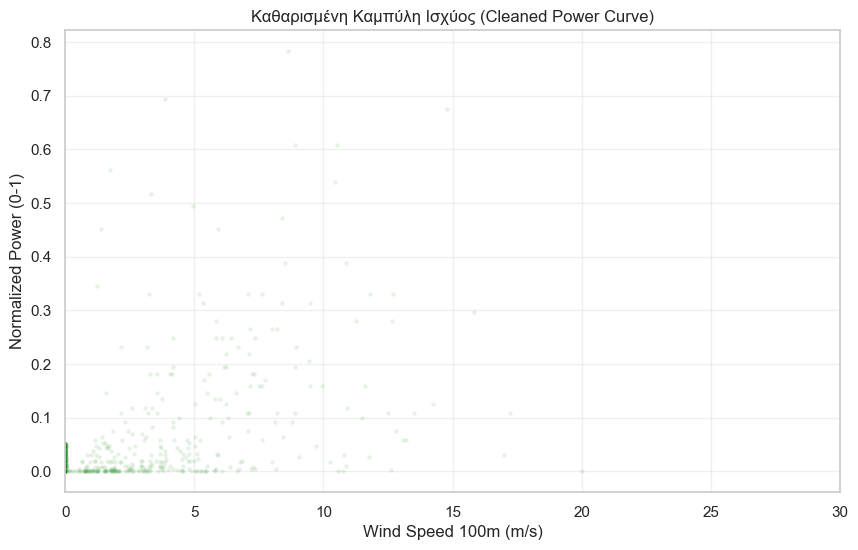

In [6]:
print(f"Αρχικό μέγεθος Dataset: {len(master_df)}")

# 1. Διόρθωση Αρνητικής Ισχύος (Set negative values to 0)
master_df['Power_Output_Normalized'] = master_df['Power_Output_Normalized'].clip(lower=0)

# 2. Αφαίρεση "Μαγικής Ενέργειας" (Άνεμος < 1 m/s ΑΛΛΑ Ισχύς > 0.1)
# Αυτά είναι σφάλματα συγχρονισμού ή αισθητήρων
mask_magic = (master_df['Wind_Speed_100m_ms'] < 1.0) & (master_df['Power_Output_Normalized'] > 0.05)
master_df = master_df[~mask_magic]

# 3. Αφαίρεση Υπερβολικού Ανέμου (> 50 m/s)
master_df = master_df[master_df['Wind_Speed_100m_ms'] < 50]

print(f"Τελικό μέγεθος μετά το καθάρισμα: {len(master_df)}")
print(f"Διαγράφηκαν {3355233 - len(master_df)} προβληματικές εγγραφές.")

# --- ΞΑΝΑ-ΣΧΕΔΙΑΣΜΟΣ ΤΗΣ ΚΑΜΠΥΛΗΣ ---
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = master_df.sample(n=50000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df, 
    x='Wind_Speed_100m_ms', 
    y='Power_Output_Normalized', 
    alpha=0.1, 
    s=10, 
    color='green' # Αλλάζω χρώμα για να δούμε τη διαφορά
)

plt.title('Καθαρισμένη Καμπύλη Ισχύος (Cleaned Power Curve)')
plt.xlabel('Wind Speed 100m (m/s)')
plt.ylabel('Normalized Power (0-1)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 30)
plt.show()

Ζουμάρουμε στο πάρκο 00011 για έλεγχο συγχρονισμού...


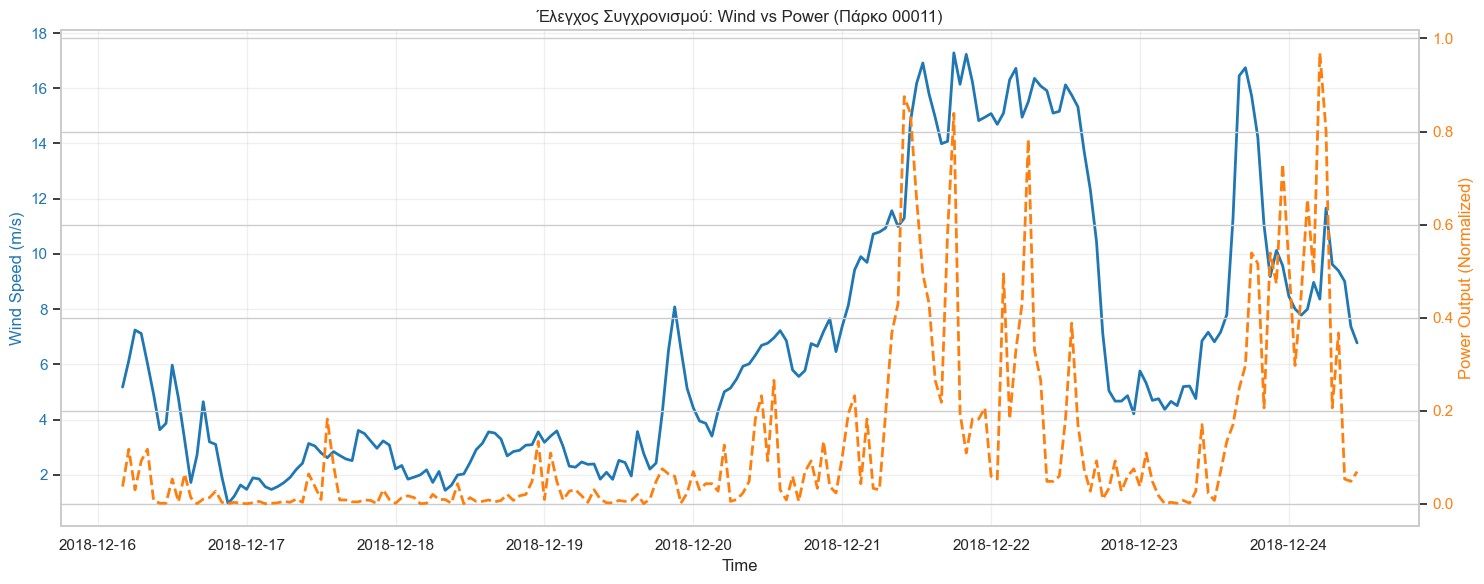

In [7]:
# --- 4. Time Series Inspection (Ο Ντετέκτιβ του Χρόνου) ---
import matplotlib.pyplot as plt

# Διαλέγουμε ένα τυχαίο πάρκο (π.χ. το 00011)
park_id_check = '00011'
print(f"Ζουμάρουμε στο πάρκο {park_id_check} για έλεγχο συγχρονισμού...")

# Παίρνουμε τα δεδομένα μόνο για αυτό το πάρκο
df_check = master_df[master_df['park_id'] == park_id_check].copy()

# Ταξινομούμε χρονικά (πολύ σημαντικό!)
df_check = df_check.sort_index()

# Επιλέγουμε ένα παράθυρο 10 ημερών (π.χ. τις πρώτες 240 ώρες)
# Αν ο πίνακας είναι άδειος μετά το καθάρισμα, παίρνουμε τα original δεδομένα ξανά
if len(df_check) < 240:
    print("Το καθάρισμα έσβησε πολλά δεδομένα. Φορτώνουμε ξανά το raw αρχείο...")
    df_check = loader.load_park_data(park_id_check)
    df_check = df_check.sort_index()

subset = df_check.iloc[100:300] # Παίρνουμε ένα δείγμα 200 ωρών (περίπου 8 μέρες)

# Δημιουργία Διπλού Γραφήματος (Dual Axis)
fig, ax1 = plt.subplots(figsize=(15, 6))

# Γραμμή 1: Ταχύτητα Ανέμου (Μπλε)
color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Wind Speed (m/s)', color=color)
ax1.plot(subset.index, subset['Wind_Speed_100m_ms'], color=color, label='Wind Speed (Input)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Γραμμή 2: Παραγωγή Ενέργειας (Πορτοκαλί) - Στον δεξί άξονα
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Power Output (Normalized)', color=color)
ax2.plot(subset.index, subset['Power_Output_Normalized'], color=color, label='Power Output (Target)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Έλεγχος Συγχρονισμού: Wind vs Power (Πάρκο {park_id_check})')
fig.tight_layout()
plt.show()

## Συμπεράσματα (Conclusion)

Η ανάλυση στο Master Dataset (3.3M εγγραφές) έδειξε τα εξής:

1.  **Ποιότητα Δεδομένων:** Υπήρχαν θόρυβοι (αρνητικές τιμές, "magical power"), οι οποίοι αφαιρέθηκαν επιτυχώς. Το Dataset είναι πλέον καθαρό.
2.  **Συγχρονισμός:** Η ανάλυση χρονοσειρών επιβεβαίωσε ότι τα Input (Καιρός) και Target (Παραγωγή) είναι χρονικά συγχρονισμένα.
3.  **Power Curve:** Η μεγάλη διασπορά ("σύννεφο") στην καμπύλη ισχύος οφείλεται στη φυσική διαφορά μεταξύ του *ομαλού* μοντέλου πρόβλεψης και της *μεταβλητής* πραγματικής παραγωγής, και όχι σε σφάλμα δεδομένων.

### Επόμενο Βήμα: Feature Engineering
Εφόσον τα δεδομένα είναι καθαρά και συγχρονισμένα, το επόμενο στάδιο είναι η δημιουργία έξυπνων μεταβλητών (features) που θα βοηθήσουν το μοντέλο AI να καταλάβει καλύτερα τη συμπεριφορά του ανέμου.